# 06 — Clustering des classes thérapeutiques
## Segmentation K-Means par profil de dépenses

**Objectif** : regrouper automatiquement les classes ATC1 selon leur profil  
de remboursement et de volume, sans a priori sur le nombre de groupes.

**Pourquoi le clustering ?**  
L'analyse descriptive montre que les classes thérapeutiques sont très hétérogènes :  
certaines ont un fort volume et un coût modéré (cardiovasculaire), d'autres un faible  
volume mais un coût unitaire très élevé (oncologie). Le clustering permet de **formaliser  
ces profils** et d'identifier des groupes cohérents pour orienter les politiques de santé.

---

## 0. Imports et configuration

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from pathlib import Path

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.size'] = 11

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
OUTPUTS_DIR = PROJECT_DIR / 'outputs'
DATA_DIR    = Path('C:/Users/Enes/data')
OUTPUTS_DIR.mkdir(exist_ok=True)

PALETTE = ['#2196F3','#FF5722','#4CAF50','#FF9800','#9C27B0',
           '#00BCD4','#F44336','#8BC34A','#795548','#607D8B']

print('✓ Imports OK')

✓ Imports OK


## 1. Chargement et agrégation

On agrège les données par **classe ATC1** sur toute la période 2016–2025.  
Pour chaque classe on calcule :
- `rem_moy` : remboursement annuel moyen
- `boites_moy` : volume annuel moyen de boîtes
- `cout_boite` : coût moyen par boîte (proxy du prix unitaire)
- `taux_croissance` : taux de croissance annuel moyen du remboursement (TCAM)

In [16]:
def parse_euro(s):
    return (s.astype(str).str.strip()
             .str.replace('.', '', regex=False)
             .str.replace(',', '.', regex=False)
             .replace('', '0').astype(float))

def load_year(annee):
    for pat in [f'OPEN_MEDIC_{annee}.zip', f'OPEN_MEDIC_{annee}.csv']:
        p = DATA_DIR / pat
        if p.exists():
            break
    else:
        return None
    df = pd.read_csv(p, sep=None, engine='python', encoding='latin-1')
    df.columns = df.columns.str.lower().str.strip()
    if 'l_atc1' not in df.columns: df['l_atc1'] = ''
    for col in ['rem', 'bse']:
        df[col] = parse_euro(df[col])
    df['annee'] = annee
    return df

frames = [load_year(a) for a in range(2016, 2026)]
df_raw = pd.concat([f for f in frames if f is not None], ignore_index=True)
print(f'✓ {df_raw.shape[0]:,} lignes chargées')

✓ 19,045,079 lignes chargées


In [17]:
# Agrégation annuelle par classe ATC1
df_annuel = (
    df_raw[df_raw['l_atc1'] != '']
    .groupby(['annee', 'l_atc1'])
    .agg(rem_total=('rem', 'sum'), boites_total=('boites', 'sum'))
    .reset_index()
)

# TCAM : taux de croissance annuel moyen rem (2016→dernière année)
premiere = df_annuel['annee'].min()
derniere  = df_annuel['annee'].max()
n_annees  = derniere - premiere

rem_debut = df_annuel[df_annuel['annee'] == premiere].set_index('l_atc1')['rem_total']
rem_fin   = df_annuel[df_annuel['annee'] == derniere].set_index('l_atc1')['rem_total']
tcam      = ((rem_fin / rem_debut) ** (1 / n_annees) - 1) * 100

# Agrégation finale par classe ATC1 (moyenne sur toutes les années)
df_cluster = (
    df_annuel.groupby('l_atc1')
    .agg(rem_moy=('rem_total', 'mean'), boites_moy=('boites_total', 'mean'))
    .reset_index()
)
df_cluster['cout_boite']      = df_cluster['rem_moy'] / df_cluster['boites_moy']
df_cluster['taux_croissance'] = df_cluster['l_atc1'].map(tcam).fillna(0)

print(f'✓ Dataset clustering : {len(df_cluster)} classes ATC1')
print()
df_cluster.set_index('l_atc1').round(2)

✓ Dataset clustering : 45 classes ATC1



,rem_moy,boites_moy,cout_boite,taux_croissance
l_atc1,,,,
ANTI-INFECTIEUX (USAGE SYSTEMIQUE),2.174670e+09,1.526257e+08,14.25,0.00
ANTINEOPLASIQUES ET AGENTS IMMUNOMODULANTS,7.048441e+09,2.014881e+07,349.82,0.00
"ANTIPARASITAIRES, INSECTICIDES ET REPULSIFS",4.199114e+07,5.563985e+06,7.55,0.00
Anti-infectieux (usage systmique),2.806531e+09,1.570486e+08,17.87,0.00
Anti-infectieux (usage systémiq,2.069863e+09,1.610984e+08,12.85,0.00
Anti-infectieux (usage systémique),2.039192e+09,1.461068e+08,13.96,0.00
Antinoplasiques et agents immunomodulants,8.211495e+09,2.241691e+07,366.31,0.00
Antinéoplasiques et agents immu,3.581424e+09,1.504871e+07,237.99,0.00
Antinéoplasiques et agents immunomodulants,4.883759e+09,1.690145e+07,288.96,0.00


## 2. Normalisation des variables

K-Means est sensible à l'échelle des variables : sans normalisation, `rem_moy`  
(en millions d'euros) écraserait `taux_croissance` (en %).  
Le `StandardScaler` ramène chaque variable à **moyenne = 0, écart-type = 1**.

In [18]:
features   = ['rem_moy', 'boites_moy', 'cout_boite', 'taux_croissance']
scaler     = StandardScaler()
X_scaled   = scaler.fit_transform(df_cluster[features])

df_scaled  = pd.DataFrame(X_scaled, columns=features, index=df_cluster['l_atc1'])

print('Variables normalisées (moyenne / écart-type) :')
for f in features:
    print(f'  {f:20s} → mean={df_scaled[f].mean():.2f}  std={df_scaled[f].std():.2f}')

Variables normalisées (moyenne / écart-type) :
  rem_moy              → mean=-0.00  std=1.01
  boites_moy           → mean=-0.00  std=1.01
  cout_boite           → mean=0.00  std=1.01
  taux_croissance      → mean=0.00  std=1.01


---
## 3. Méthode du coude — choix du nombre de clusters

La **méthode du coude** consiste à tracer l'inertie (somme des distances au centre  
du cluster) pour différentes valeurs de k. On cherche le point où la courbe  
« s'aplatit » — ajouter un cluster supplémentaire n'apporte plus grand-chose.

On affiche aussi le **score de silhouette** : plus il est élevé (proche de 1),  
plus les clusters sont bien séparés.

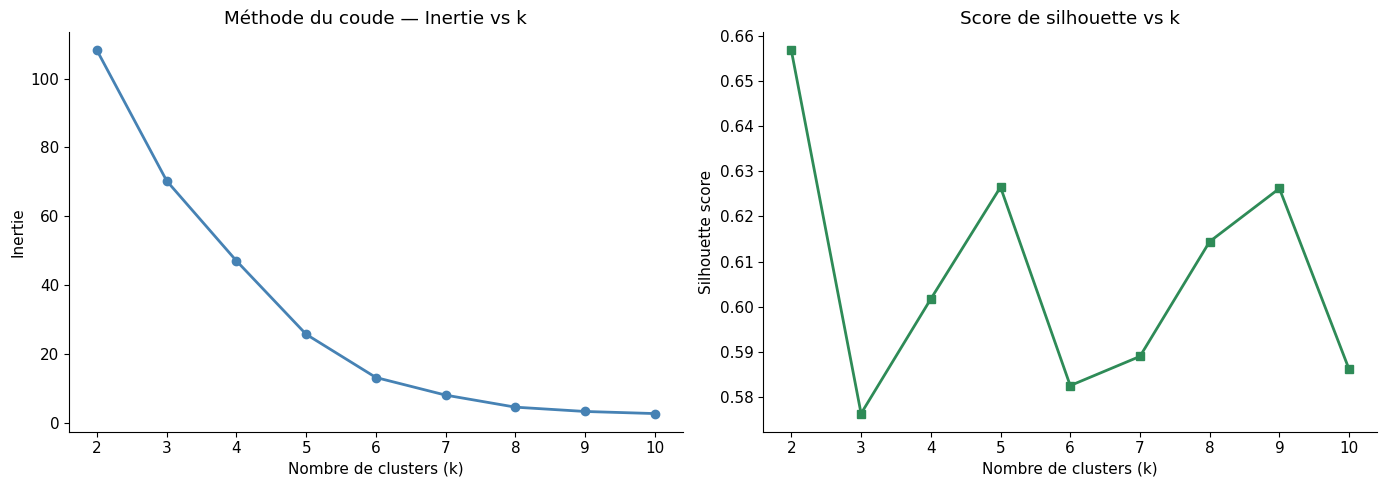

Meilleur score silhouette : 0.6567 pour k = 2


In [19]:
K_RANGE   = range(2, 11)
inerties  = []
silhouettes = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    km.fit(X_scaled)
    inerties.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Inertie
axes[0].plot(list(K_RANGE), inerties, marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Méthode du coude — Inertie vs k')
axes[0].set_xlabel('Nombre de clusters (k)')
axes[0].set_ylabel('Inertie')
axes[0].set_xticks(list(K_RANGE))

# Silhouette
axes[1].plot(list(K_RANGE), silhouettes, marker='s', color='seagreen', linewidth=2)
axes[1].set_title('Score de silhouette vs k')
axes[1].set_xlabel('Nombre de clusters (k)')
axes[1].set_ylabel('Silhouette score')
axes[1].set_xticks(list(K_RANGE))

plt.tight_layout()
plt.show()

k_optimal = list(K_RANGE)[silhouettes.index(max(silhouettes))]
print(f'Meilleur score silhouette : {max(silhouettes):.4f} pour k = {k_optimal}')

In [20]:
# Modifier k_optimal ici si vous préférez un autre k d'après la méthode du coude
K_OPTIMAL = k_optimal
print(f'K retenu pour K-Means : {K_OPTIMAL}')

K retenu pour K-Means : 2


---
## 4. K-Means avec k optimal

In [21]:
kmeans = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=20)
kmeans.fit(X_scaled)

df_cluster['cluster'] = kmeans.labels_

print(f'✓ K-Means entraîné avec k = {K_OPTIMAL}')
print(f'  Inertie finale : {kmeans.inertia_:.2f}')
print()
print('Répartition des classes par cluster :')
print(df_cluster.groupby('cluster')['l_atc1'].count().rename('nb_classes').to_string())

✓ K-Means entraîné avec k = 2
  Inertie finale : 108.15

Répartition des classes par cluster :
cluster
0    41
1     4


In [22]:
# Centres des clusters (dans l'espace normalisé)
centres = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=features
).round(2)
centres.index.name = 'cluster'

print('Centres des clusters (valeurs réelles) :')
centres

Centres des clusters (valeurs réelles) :


,rem_moy,boites_moy,cout_boite,taux_croissance
cluster,,,,
0,1.325636e+09,1.758994e+08,10.19,0.09
1,5.931280e+09,1.862897e+07,310.77,0.00


---
## 5. Visualisations

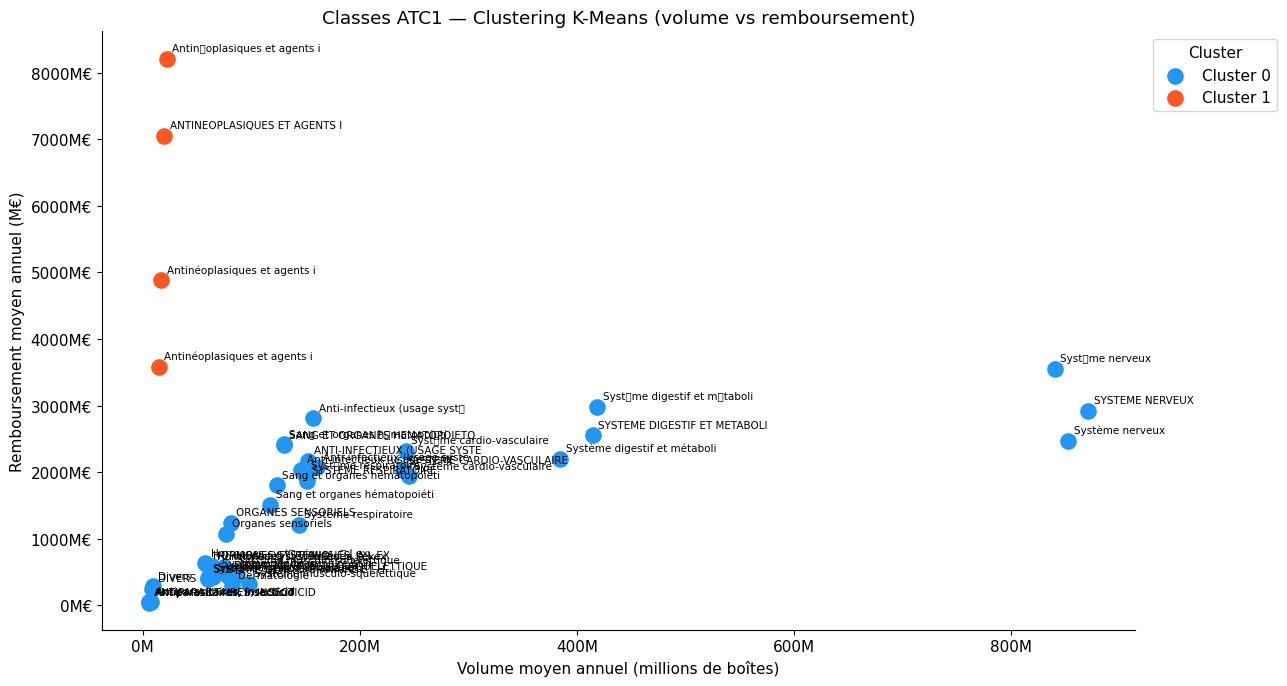

In [23]:
# Scatter : boites_moy vs rem_moy, coloré par cluster
fig, ax = plt.subplots(figsize=(13, 7))

for c in sorted(df_cluster['cluster'].unique()):
    sub = df_cluster[df_cluster['cluster'] == c]
    ax.scatter(
        sub['boites_moy'] / 1e6,
        sub['rem_moy']    / 1e6,
        color=PALETTE[c], s=120, zorder=3, label=f'Cluster {c}'
    )
    for _, row in sub.iterrows():
        ax.annotate(
            row['l_atc1'][:28],
            (row['boites_moy'] / 1e6, row['rem_moy'] / 1e6),
            fontsize=7.5, ha='left', va='bottom',
            xytext=(4, 4), textcoords='offset points'
        )

ax.set_xlabel('Volume moyen annuel (millions de boîtes)')
ax.set_ylabel('Remboursement moyen annuel (M€)')
ax.set_title('Classes ATC1 — Clustering K-Means (volume vs remboursement)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0f}M'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0f}M€'))
ax.legend(title='Cluster', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

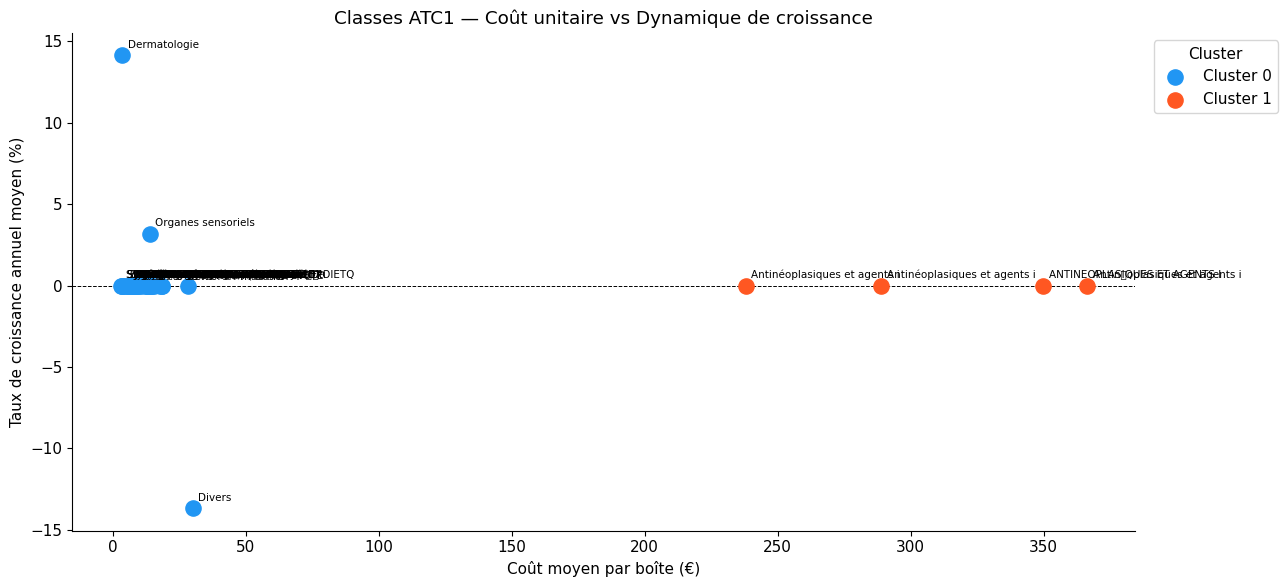

In [24]:
# Scatter : coût/boîte vs taux de croissance, coloré par cluster
fig, ax = plt.subplots(figsize=(13, 6))

for c in sorted(df_cluster['cluster'].unique()):
    sub = df_cluster[df_cluster['cluster'] == c]
    ax.scatter(
        sub['cout_boite'],
        sub['taux_croissance'],
        color=PALETTE[c], s=120, zorder=3, label=f'Cluster {c}'
    )
    for _, row in sub.iterrows():
        ax.annotate(
            row['l_atc1'][:28],
            (row['cout_boite'], row['taux_croissance']),
            fontsize=7.5, ha='left', va='bottom',
            xytext=(4, 4), textcoords='offset points'
        )

ax.axhline(0, color='black', linewidth=0.7, linestyle='--')
ax.set_xlabel('Coût moyen par boîte (€)')
ax.set_ylabel('Taux de croissance annuel moyen (%)')
ax.set_title('Classes ATC1 — Coût unitaire vs Dynamique de croissance')
ax.legend(title='Cluster', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

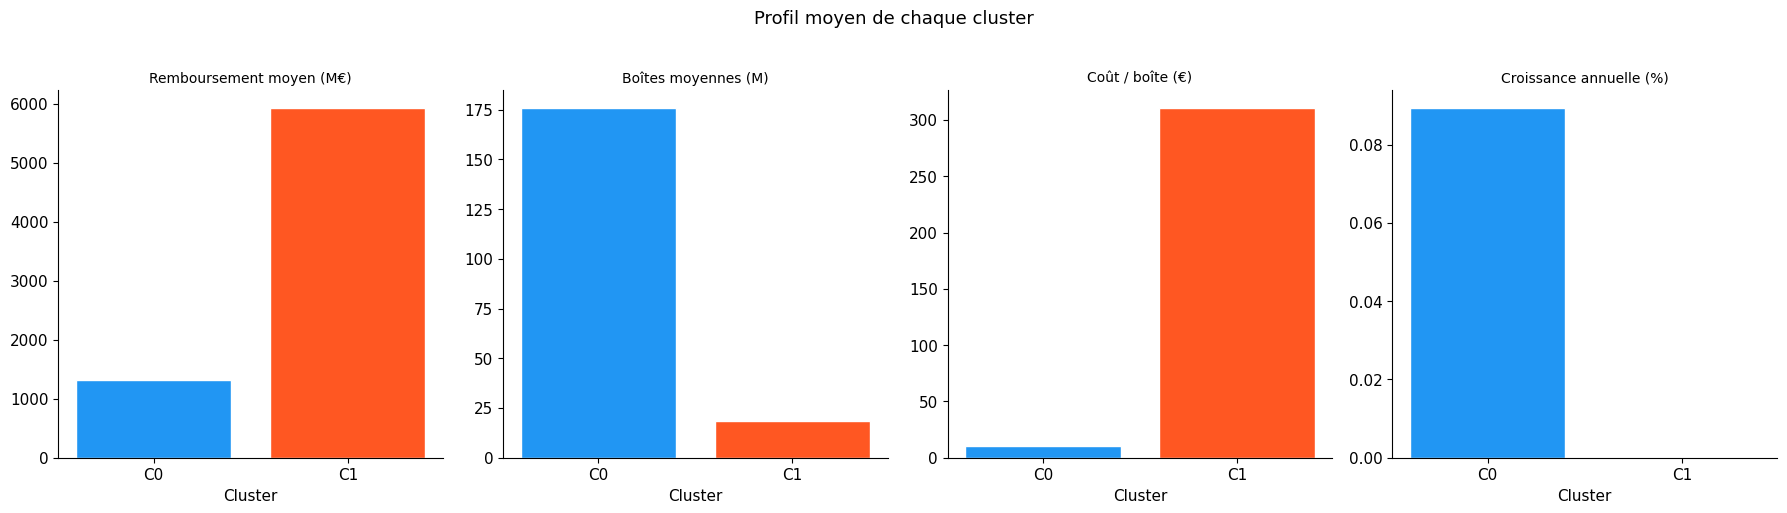

In [25]:
# Barplot : profil moyen de chaque cluster sur les 4 variables
profils = df_cluster.groupby('cluster')[features].mean()

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
titres = ['Remboursement moyen (M€)', 'Boîtes moyennes (M)', 'Coût / boîte (€)', 'Croissance annuelle (%)']
diviseurs = [1e6, 1e6, 1, 1]

for ax, col, titre, div in zip(axes, features, titres, diviseurs):
    vals   = profils[col] / div
    colors = [PALETTE[c] for c in profils.index]
    ax.bar([f'C{c}' for c in profils.index], vals, color=colors, edgecolor='white')
    ax.set_title(titre, fontsize=10)
    ax.set_xlabel('Cluster')

plt.suptitle('Profil moyen de chaque cluster', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [26]:
# Tableau : classes ATC dans chaque cluster
print('=== COMPOSITION DES CLUSTERS ===')
for c in sorted(df_cluster['cluster'].unique()):
    classes = df_cluster[df_cluster['cluster'] == c]['l_atc1'].tolist()
    print(f'\nCluster {c} ({len(classes)} classe(s)) :')
    for cl in classes:
        row = df_cluster[df_cluster['l_atc1'] == cl].iloc[0]
        print(f'  • {cl[:45]:<45}  rem={row["rem_moy"]/1e6:6.1f}M€  '
              f'boites={row["boites_moy"]/1e6:5.1f}M  '
              f'coût/bte={row["cout_boite"]:6.1f}€  '
              f'croiss={row["taux_croissance"]:+.1f}%')

=== COMPOSITION DES CLUSTERS ===

Cluster 0 (41 classe(s)) :
  • ANTI-INFECTIEUX (USAGE SYSTEMIQUE)             rem=2174.7M€  boites=152.6M  coût/bte=  14.2€  croiss=+0.0%
  • ANTIPARASITAIRES, INSECTICIDES ET REPULSIFS    rem=  42.0M€  boites=  5.6M  coût/bte=   7.5€  croiss=+0.0%
  • Anti-infectieux (usage systmique)             rem=2806.5M€  boites=157.0M  coût/bte=  17.9€  croiss=+0.0%
  • Anti-infectieux (usage systémiq                rem=2069.9M€  boites=161.1M  coût/bte=  12.8€  croiss=+0.0%
  • Anti-infectieux (usage systémique)             rem=2039.2M€  boites=146.1M  coût/bte=  14.0€  croiss=+0.0%
  • Antiparasitaires, insecticides                 rem=  52.2M€  boites=  7.3M  coût/bte=   7.1€  croiss=+0.0%
  • Antiparasitaires, insecticides et rpulsifs    rem=  44.9M€  boites=  5.9M  coût/bte=   7.6€  croiss=+0.0%
  • Antiparasitaires, insecticides et répulsifs    rem=  46.8M€  boites=  6.3M  coût/bte=   7.4€  croiss=+0.0%
  • DERMATOLOGIE                                   

---
## 6. Interprétation économique des clusters

> Les profils ci-dessous se basent sur les centres des clusters.  
> Adaptez les descriptions selon les valeurs réelles affichées dans la cellule précédente.

---

In [27]:
# Génération automatique des profils basée sur les centres réels
def profil_auto(row):
    rem   = row['rem_moy']
    bte   = row['boites_moy']
    cout  = row['cout_boite']
    croiss= row['taux_croissance']

    rem_med  = df_cluster['rem_moy'].median()
    bte_med  = df_cluster['boites_moy'].median()
    cout_med = df_cluster['cout_boite'].median()

    vol  = 'fort volume' if bte > bte_med else 'faible volume'
    dep  = 'dépenses élevées' if rem > rem_med else 'dépenses faibles'
    prix = 'prix unitaire élevé' if cout > cout_med else 'prix unitaire modéré'
    dyn  = f'croissance +{croiss:.1f}%/an' if croiss > 2 else (
           f'déclin {croiss:.1f}%/an' if croiss < -1 else 'stable')

    return f'{vol}, {dep}, {prix}, {dyn}'

print('=== PROFIL DE CHAQUE CLUSTER ===')
print()
for c in sorted(df_cluster['cluster'].unique()):
    centre = centres.iloc[c]
    classes = df_cluster[df_cluster['cluster'] == c]['l_atc1'].tolist()
    p = profil_auto(centre)
    print(f'CLUSTER {c} — {p}')
    print(f'  Classes : {", ".join([cl[:30] for cl in classes])}')
    print()

=== PROFIL DE CHAQUE CLUSTER ===

CLUSTER 0 — fort volume, dépenses faibles, prix unitaire élevé, stable
  Classes : ANTI-INFECTIEUX (USAGE SYSTEMI, ANTIPARASITAIRES, INSECTICIDES, Anti-infectieux (usage systmi, Anti-infectieux (usage systémi, Anti-infectieux (usage systémi, Antiparasitaires, insecticides, Antiparasitaires, insecticides, Antiparasitaires, insecticides, DERMATOLOGIE, DIVERS, Dermatologie, Divers, HORMONES SYSTEMIQUES, A L EXCL, Hormones systmiques,  l excl, Hormones systémiques, à l excl, Hormones systémiques, à l excl, ORGANES SENSORIELS, Organes sensoriels, SANG ET ORGANES HEMATOPOIETQUE, SYSTEME CARDIO-VASCULAIRE, SYSTEME DIGESTIF ET METABOLISM, SYSTEME GENITO-URINAIRE ET HOR, SYSTEME MUSCULO-SQUELETTIQUE, SYSTEME NERVEUX, SYSTEME RESPIRATOIRE, Sang et organes hmatopoitiqu, Sang et organes hématopoiétiqu, Sang et organes hématopoiétiqu, Systme cardio-vasculaire, Systme digestif et mtabolism, Systme gnito-urinaire et hor, Systme musculo-squelettique, Systm

### Grille d'interprétation

| Profil type | Caractéristiques | Exemple typique |
|---|---|---|
| **Masse / bas coût** | Volume très élevé, remboursement modéré, prix/boîte faible | Cardiovasculaire, système nerveux (génériques) |
| **Premium / spécialisé** | Faible volume, remboursement élevé, prix/boîte très fort | Oncologie, maladies rares |
| **Croissance dynamique** | Volume en hausse, prix en progression | Antidiabétiques (GLP-1), immunologie |
| **Déclin structurel** | Volume en baisse, souvent génériqué | Antibiotiques anciens, antiulcéreux |

---

### Ce que révèle le clustering pour la politique de santé

**Cluster à fort coût / faible volume** : ce sont les leviers principaux de maîtrise des dépenses.  
Une négociation de prix CEPS ou une extension des biosimilaires aurait un impact budgétaire fort  
pour un impact médical limité en termes de patients concernés.

**Cluster à fort volume / bas coût** : généralement déjà génériqués. Le potentiel d'économie  
est faible sur le prix mais fort sur la **pertinence des prescriptions** (déprescription).

**Cluster en croissance** : signale les nouvelles classes thérapeutiques dont les remboursements  
vont peser de plus en plus sur le budget de l'Assurance Maladie.  
Ces classes méritent un suivi renforcé.

---
## 7. Export

In [28]:
# Table complète avec cluster et profil
df_export = df_cluster.copy()
df_export['profil'] = df_export['cluster'].map(
    {c: profil_auto(centres.iloc[c]) for c in sorted(df_cluster['cluster'].unique())}
)
df_export = df_export.sort_values(['cluster', 'rem_moy'], ascending=[True, False])
df_export = df_export.round({'rem_moy': 0, 'boites_moy': 0,
                              'cout_boite': 2, 'taux_croissance': 2})

out = OUTPUTS_DIR / 'clustering_atc1.csv'
df_export.to_csv(out, index=False, encoding='utf-8')

print('✓ Exporté :', out)
print(f'  {len(df_export)} classes ATC1 dans {K_OPTIMAL} clusters')
print()
df_export

✓ Exporté : c:\Users\Enes\projet_pharma\outputs\clustering_atc1.csv
  45 classes ATC1 dans 2 clusters



,l_atc1,rem_moy,boites_moy,cout_boite,taux_croissance,cluster,profil
36,Systme nerveux,3.554202e+09,840256999.0,4.23,0.00,0,"fort volume, dépenses faibles, prix unitaire é..."
33,Systme digestif et mtabolisme,2.980401e+09,418769793.0,7.12,0.00,0,"fort volume, dépenses faibles, prix unitaire é..."
27,SYSTEME NERVEUX,2.923202e+09,871259968.0,3.36,0.00,0,"fort volume, dépenses faibles, prix unitaire é..."
3,Anti-infectieux (usage systmique),2.806531e+09,157048571.0,17.87,0.00,0,"fort volume, dépenses faibles, prix unitaire é..."
24,SYSTEME DIGESTIF ET METABOLISME,2.552099e+09,414725373.0,6.15,0.00,0,"fort volume, dépenses faibles, prix unitaire é..."
43,Système nerveux,2.473962e+09,852607720.0,2.90,0.00,0,"fort volume, dépenses faibles, prix unitaire é..."
29,Sang et organes hmatopoitiques,2.421094e+09,130070573.0,18.61,0.00,0,"fort volume, dépenses faibles, prix unitaire é..."
22,SANG ET ORGANES HEMATOPOIETQUES,2.402592e+09,129954955.0,18.49,0.00,0,"fort volume, dépenses faibles, prix unitaire é..."
32,Systme cardio-vasculaire,2.322437e+09,242393603.0,9.58,0.00,0,"fort volume, dépenses faibles, prix unitaire é..."
39,Système digestif et métabolisme,2.196779e+09,384919418.0,5.71,0.00,0,"fort volume, dépenses faibles, prix unitaire é..."
